In [94]:
import numpy as np
import matplotlib.pyplot as plt
from simulate_data_script import X_design, beta_sparse, y_tobit

n, d = 10_000, 5_000
pi0 = 0.005
tau2 = 4
rng = np.random.default_rng(42)

X = X_design(n, d, "corr_blocks", k = 25, corr = 0.7, intercept=True, rng=rng)

n, d_total = X.shape 

beta = beta_sparse(d_total, np.sqrt(tau2), pi0, rng)

ystar, l, u, sigma_y_true = y_tobit(X, beta, 20, 80, 1, rng)

y = np.clip(ystar, l,u)

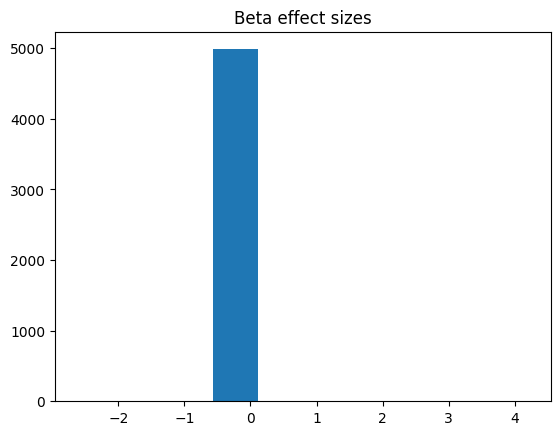

Text(0.5, 1.0, 'OLS estimates using latent y')

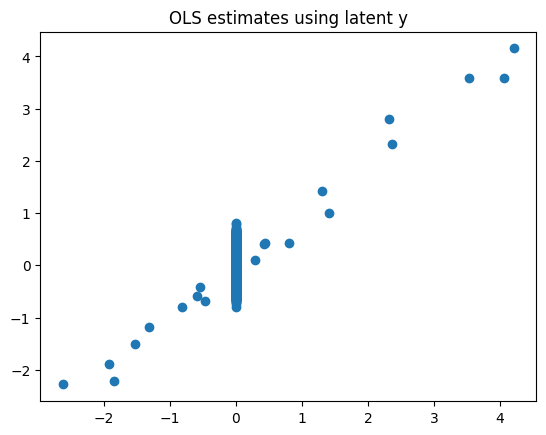

In [95]:
plt.hist(beta)
plt.title("Beta effect sizes")
plt.show()

beta_est = np.linalg.inv(X.T @ X) @ X.T @ ystar
plt.scatter(beta, beta_est)
plt.title("OLS estimates using latent y")



Block sizes: [ 1 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25]
Number of blocks: 201


In [96]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components


def estimate_blocks(X, tol=1e-8):
    """
    Estimate block structure of a (block-diagonal, up to column permutation)
    matrix X, assuming columns belonging to the same block are contiguous.

    Parameters
    ----------
    X : (n, d) array
        Design matrix, assumed block-diagonal in structure (i.e. the column
        correlation matrix has a block-diagonal pattern once columns are
        grouped correctly).
    tol : float
        Threshold, in correlation units (i.e. after normalizing to unit
        column norm), below which two columns are treated as disconnected.

    Returns
    -------
    beta_blocks : (d,) array of int
        Block id for each column, e.g. [0, 0, 0, 1, 1, 2, 2, 2, ...].
    """
    # Normalize columns to unit norm, so that G becomes a correlation-like
    # matrix with entries in [-1, 1], independent of column scale and n
    norms = np.linalg.norm(X, axis=0)
    norms[norms == 0] = 1.0  # avoid division by zero for all-zero columns
    X_normalized = X / norms

    G = X_normalized.T @ X_normalized
    adjacency = csr_matrix(np.abs(G) > tol)

    n_components, labels = connected_components(
        adjacency, directed=False, connection="weak"
    )

    # Relabel blocks in order of first appearance, following column order
    beta_blocks = np.empty_like(labels)
    seen = {}
    next_id = 0
    for j, lbl in enumerate(labels):
        if lbl not in seen:
            seen[lbl] = next_id
            next_id += 1
        beta_blocks[j] = seen[lbl]

    return beta_blocks

def plot_beta_with_block_summary(m, beta, beta_blocks, agg="sum"):
    """
    Top panel: coordinate-wise m vs true beta.
    Bottom panel: block-level aggregated signal (step plot), same for both.
    """
    unique_blocks = np.unique(beta_blocks)
    agg_fn = np.sum if agg == "sum" else np.mean

    m_block = np.zeros_like(m, dtype=float)
    beta_block = np.zeros_like(beta, dtype=float)
    for k in unique_blocks:
        idx = np.where(beta_blocks == k)[0]
        m_block[idx] = agg_fn(m[idx])
        beta_block[idx] = agg_fn(beta[idx])

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Top: coordinate-wise values
    axes[0].plot(m, label="m (variational mean)", marker="o", markersize=3)
    axes[0].plot(beta, label="beta (true)", marker="x", markersize=3)
    axes[0].set_ylabel("Coefficient value")
    axes[0].legend()
    axes[0].set_title("Coordinate-wise estimate vs truth")

    # Mark block boundaries
    boundaries = np.where(np.diff(beta_blocks) != 0)[0] + 0.5
    for b in boundaries:
        axes[0].axvline(b, color="gray", linewidth=0.5, linestyle="--")
        axes[1].axvline(b, color="gray", linewidth=0.5, linestyle="--")

    # Bottom: block-level aggregated signal (step plot)
    axes[1].step(np.arange(len(m)), m_block, where="mid", label=f"m ({agg} per block)")
    axes[1].step(np.arange(len(beta)), beta_block, where="mid", label=f"beta ({agg} per block)")
    axes[1].set_xlabel("Coordinate index j")
    axes[1].set_ylabel(f"Block-level {agg}")
    axes[1].legend()
    axes[1].set_title("Block-aggregated signal")

    plt.tight_layout()
    plt.show()


def plot_beta_blocks(beta_blocks):
    """Visualize block assignment per coordinate as a color-coded strip."""
    d = len(beta_blocks)
    fig, ax = plt.subplots(figsize=(max(6, d * 0.15), 1.5))

    ax.imshow(
        beta_blocks[np.newaxis, :],
        aspect="auto",
        cmap="tab20",
        interpolation="nearest",
    )
    ax.set_yticks([])
    ax.set_xlabel("Coordinate index j")
    ax.set_title(f"Estimated block assignment ({len(np.unique(beta_blocks))} blocks)")

    # Mark block boundaries with vertical lines
    boundaries = np.where(np.diff(beta_blocks) != 0)[0] + 0.5
    for b in boundaries:
        ax.axvline(b, color="black", linewidth=0.8)

    plt.tight_layout()
    plt.show()

beta_blocks = estimate_blocks(X, tol=0.5)

plot_beta_blocks(beta_blocks)

print("Block sizes:", np.bincount(beta_blocks))
print("Number of blocks:", len(np.unique(beta_blocks)))

MFVI:   0%|          | 0/1100 [00:00<?, ?it/s]

Early stopping


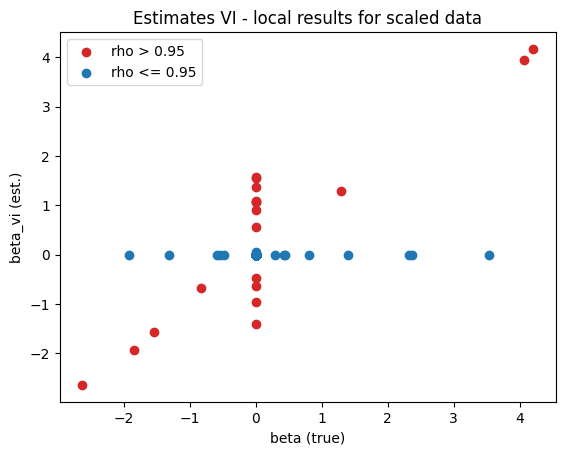

Text(0.5, 1.0, 'ELBO history')

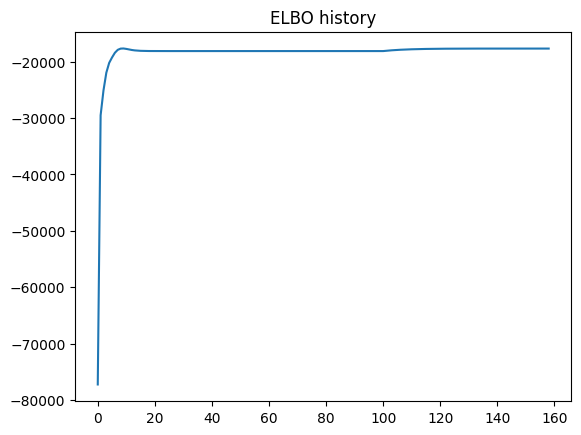

In [97]:
import aux_functions as aux_f
from mfvi_script import summary_orig
import mfvi_blocks_script
from importlib import reload
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI
    
y_scaled, sigma_y_scaled, l_scaled, u_scaled, mu_y, sd_y = aux_f.scale_y(y, l, u, sigma_y_true)


model_vi = SparseTobitStructuredVI(
    X, y_scaled,
    beta_blocks =beta_blocks,
    tau2= 1,
    pi0= 0.1, 
    seed= 22,
)

model_vi.fit(
    n_iter = 1000, 
    em_warmup = 100, 
    gamma_batch_size = 1,
    damping = 0.1
)

summary = model_vi.summary()
summary["n_iters"] = len(model_vi.elbo_history)
summary = summary_orig(summary, mu_y, sd_y, 0)

beta_vi = summary["m"]

mask = summary["rho"] > 0.95

plt.scatter(beta[mask], beta_vi[mask], color="tab:red", label="rho > 0.95")
plt.scatter(beta[~mask], beta_vi[~mask], color="tab:blue", label="rho <= 0.95")
plt.title("Estimates VI - local results for scaled data")
plt.xlabel("beta (true)")
plt.ylabel("beta_vi (est.)")
plt.legend()
plt.show()

plt.plot(model_vi.elbo_history)
plt.title("ELBO history")

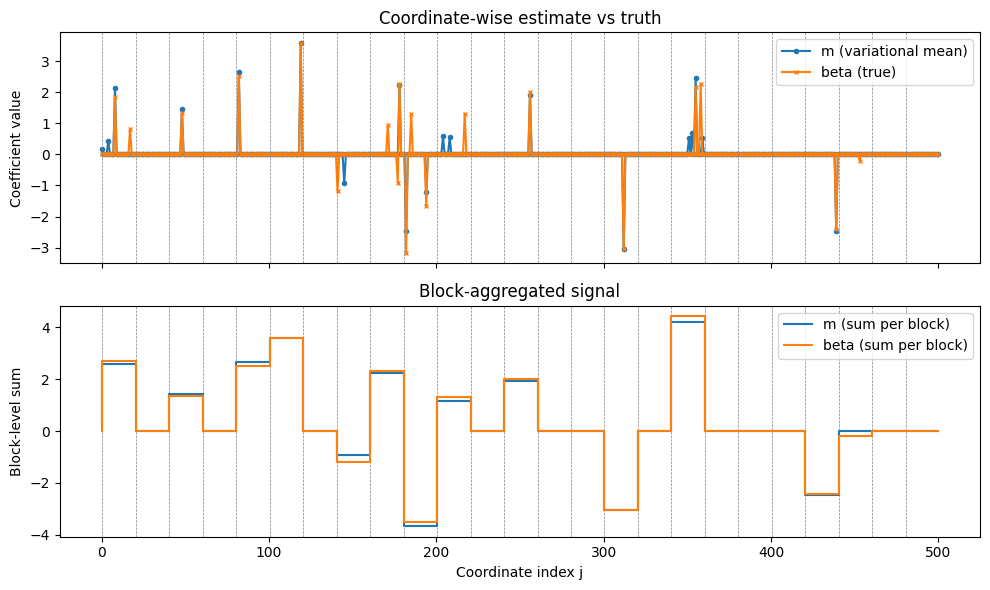

In [93]:
import matplotlib.pyplot as plt
import numpy as np

plot_beta_with_block_summary(summary["m"], beta, beta_blocks, agg="sum")

MFVI:   0%|          | 0/1100 [00:00<?, ?it/s]

Early stopping


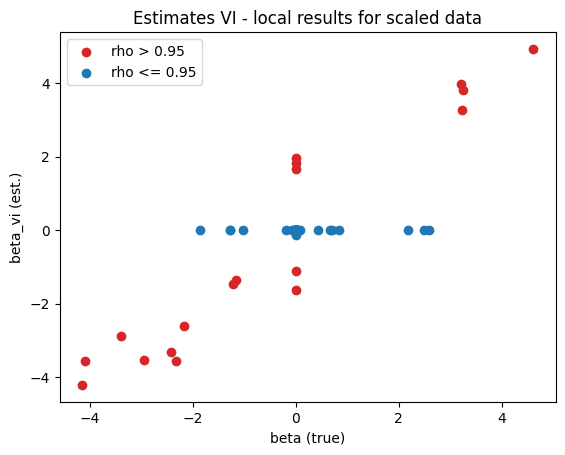

Text(0.5, 1.0, 'ELBO history')

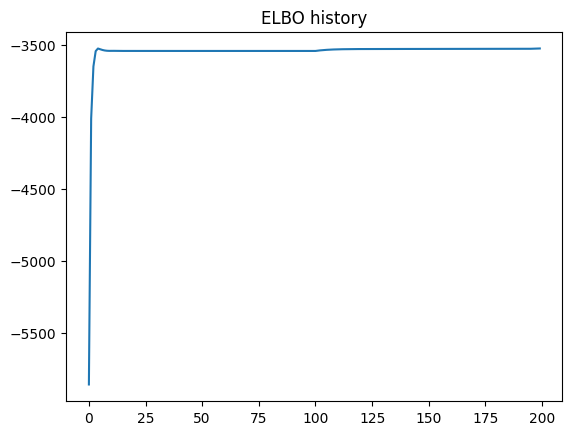

In [87]:
import aux_functions as aux_f
from mfvi_script import summary_orig
from mfvi_script import SparseTobitVI
    
y_scaled, sigma_y_scaled, l_scaled, u_scaled, mu_y, sd_y = aux_f.scale_y(y, l, u, sigma_y_true)


model_vi = SparseTobitVI(
    X, y_scaled,
    tau2= 1,
    pi0= 0.1, 
    seed= 22,
)

model_vi.fit(
    n_iter = 1000, 
    em_warmup = 100, 
    gamma_batch_size = 1,
    damping = 0.1
)

summary = model_vi.summary()
summary["n_iters"] = len(model_vi.elbo_history)
summary = summary_orig(summary, mu_y, sd_y, 0)

beta_vi = summary["m"]

mask = summary["rho"] > 0.95

plt.scatter(beta[mask], beta_vi[mask], color="tab:red", label="rho > 0.95")
plt.scatter(beta[~mask], beta_vi[~mask], color="tab:blue", label="rho <= 0.95")
plt.title("Estimates VI - local results for scaled data")
plt.xlabel("beta (true)")
plt.ylabel("beta_vi (est.)")
plt.legend()
plt.show()

plt.plot(model_vi.elbo_history)
plt.title("ELBO history")

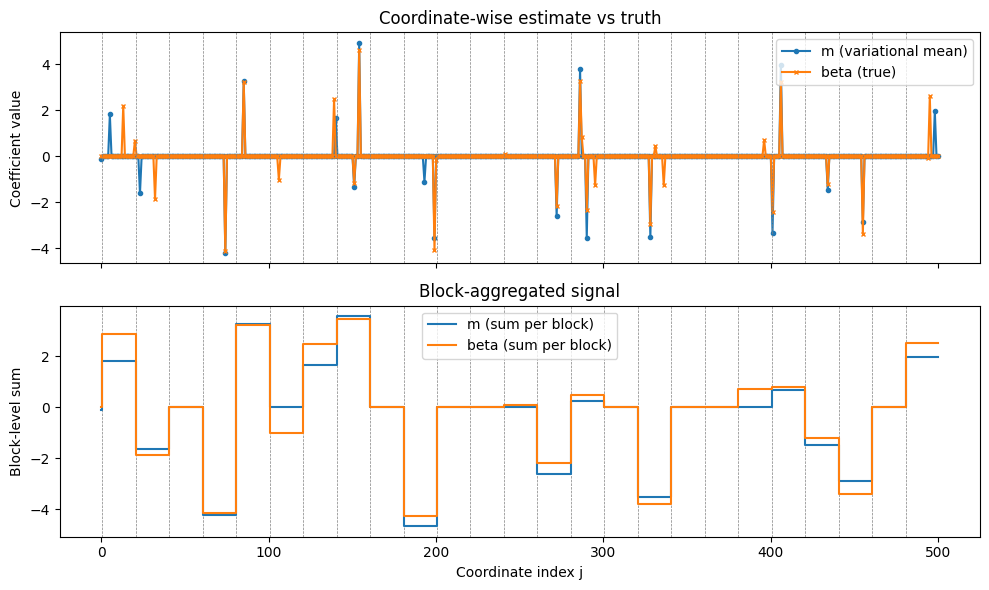

In [88]:
plot_beta_with_block_summary(summary["m"], beta, beta_blocks, agg="sum")